# Linear Regression with Medical Insurance Cost Data

## ✨ Introduction
Welcome to your first hands-on machine learning notebook! In this notebook, you’ll apply everything you've learned about regression analysis using a real-world dataset. You'll learn how to:

- Explore and prepare data
- Build simple and multiple linear regression models
- Evaluate model performance with real metrics
- Interpret model coefficients and refine your model

We’ll be using the **Medical Cost Personal Dataset** from Kaggle to predict **insurance charges** based on demographic and health-related features.

📌 **Dataset Link:** [https://www.kaggle.com/datasets/mirichoi0218/insurance/data](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)  
📜 **License:** Open Database License (ODbL) – Free to use for learning

### 📋 Features:
- `age`: Age of the individual
- `sex`: Gender (male/female)
- `bmi`: Body Mass Index
- `children`: Number of dependents
- `smoker`: Smoking status
- `region`: Residential region in the U.S.
- `charges`: Medical insurance cost (target variable)}

---

## 🧹 Preprocessing Overview for Linear Regression
Before building regression models, proper preprocessing is essential:

- **Encode categorical features**: Convert `sex`, `smoker`, and `region` into numeric using one-hot encoding.
- **Scale numerical features**: Use `StandardScaler` for features like `age`, `bmi`, and `charges`.
- **Handle outliers**: Outliers have a big influence on linear models. Always visualize and consider transforming or capping them.
- **Avoid data leakage**: Fit scalers **only on training data** before applying to test data.

---

## 🧰 Step 0: Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

---

## 📦 Step 1: Load and Explore the Dataset

In [3]:
# Load dataset
df = pd.read_csv("../data/insurance.csv")

# Basic overview
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


This shows the first five rows of the dataset, confirming that it contains columns like `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and `charges`.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The output confirms that:
- The data contains 1338 entries and 7 variables
- `age`, `bmi`, `children`, and `charges` are numeric
- `sex`, `smoker`, and `region` are categorical
- No missing values are present

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- The average age is ~39 years
- Average BMI is ~30.6
- Insurance charges range widely from $1,121 to $63,770

In [7]:
df.describe(include=['object'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


- Most individuals are male, non-smokers, and from the southeast region

---

## 📊 Step 2: Visualize Relationships and Correlation

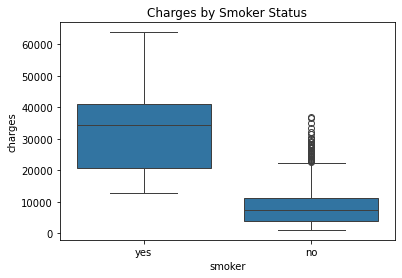

In [8]:
# Boxplot to visualize outliers
sns.boxplot(data=df, x='smoker', y='charges')
plt.title("Charges by Smoker Status")
plt.show()

> Charges are significantly higher for smokers, with a higher median and larger spread.

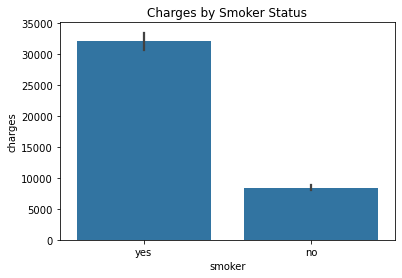

In [12]:
# Barplot to visualize distribution of Charges by Smoker Status
sns.barplot(data=df, x='smoker', y='charges')
plt.title("Charges by Smoker Status")
plt.show()

> Smokers are charged over 30,000 USD on average, compared to less than 9,000 USD for non-smokers.

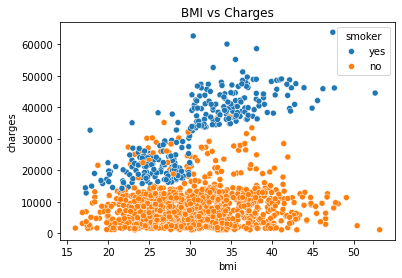

In [9]:
# Scatterplot for BMI vs Charges
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title("BMI vs Charges")
plt.show()

> For smokers, higher BMI correlates with significantly higher charges. Non-smokers show less variation.
>
> The relationship is non-linear with some extreme outliers, particularly among smokers.

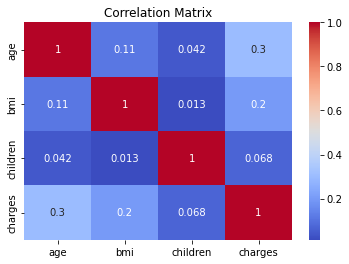

In [11]:
# Correlation matrix
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

`charges` has moderate correlation with `age`, `bmi`, and `children`, but visualizations suggest stronger non-linear patterns especially for `smoker`.

### ⚠️ Dealing with Outliers (Important Note)
Although we've visualized potential outliers in features like `bmi` and `charges`, we have not handled them in code. In a professional workflow, addressing outliers is crucial because they can heavily skew a linear regression model.

**Common approaches include:**
- **IQR filtering** to remove values beyond the typical range
- **Capping** extreme values at a threshold (also known as winsorizing)
- **Log transformation** to reduce skewness, especially for `charges`

Outlier handling was not applied here to preserve the raw dataset, but you are encouraged to explore it further and test how it impacts model performance.

---

## 🧪 Step 3: Simple Linear Regression (BMI → Charges)

In [14]:
X = df[['bmi']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

We use BMI as the only predictor. This is a simple linear model.

In [29]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_simple)

print(f"MAE: ${mae:.2f}\nRMSE: ${rmse:.2f}\nR²: {r2:.3f}")

MAE: $9784.65
RMSE: $12210.04
R²: 0.040


The model returns:
- **MAE**: Around $9784.65 
- **RMSE**: Larger, due to squaring large errors
- **R²**: Low, around 0.04 → BMI alone doesn't explain much variance in charges

> The model is not very predictive with only one feature. Low R² means BMI alone explains little of the variation. Also note: assumptions like linearity and homoscedasticity may not fully hold with just BMI.

---

## 🧩 Step 4: Multiple Linear Regression (All Features)

In [16]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


> Categorical variables are now binary. For example, `smoker_yes = 1` means the individual is a smoker.

In [17]:
# Split data
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We split the data before scaling to avoid **data leakage**.

In [37]:
# Scale only numerical features, keep binary columns unchanged
numeric_cols = ['age', 'bmi', 'children']
binary_cols = [col for col in X.columns if col not in numeric_cols]

scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled_num = scaler.transform(X_test[numeric_cols])

# Recombine scaled numeric with untouched binary columns
X_train_scaled = np.concatenate([X_train_scaled_num, X_train[binary_cols].values], axis=1)
X_test_scaled = np.concatenate([X_test_scaled_num, X_test[binary_cols].values], axis=1)

> We apply scaling **only to numerical features** (`age`, `bmi`, `children`). Binary columns like `smoker_yes`, `sex_male`, and `region_*` remain as-is since they are already on a comparable scale (0 or 1) and scaling them can distort interpretation. This approach preserves their binary meaning and avoids unintended effects on model training.. Binary columns (`smoker_yes`, `sex_male`, etc.) remain valid as 0/1 and do not require scaling.

In [38]:
# Train model
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

y_pred_multi = model_multi.predict(X_test_scaled)

In [39]:
# Evaluate performance
mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"MAE: ${mae_multi:.2f}\nRMSE: ${rmse_multi:.2f}\nR²: {r2_multi:.3f}")

MAE: $4181.19
RMSE: $5796.28
R²: 0.784


This time:
- **MAE** drops to around $4181.19
- **R²** improves to ~0.78 → model now explains about 78% of variance in charges

Major improvement by using all features and preprocessing properly.

> A big improvement! Our model now explains nearly 78% of the variance. The error dropped by more than half.

---

## 📌 Step 5: Feature Impact (Coefficients)

In [22]:
# Coefficients and their feature names
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_multi.coef_
})
coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,smoker_yes,9558.481409
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-9.293101
5,region_northwest,-158.140981
6,region_southeast,-290.157047
7,region_southwest,-349.110678


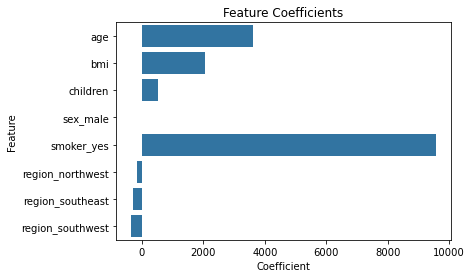

In [32]:
# Visualize Coeficients
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title("Feature Coefficients")
plt.show()

**Top predictors:**
- `smoker_yes`: most positive effect on charges
- `age`, `bmi`, `children`: moderate positive impact
- `region`, `sex_male`: minimal or slightly negative influence

> Coefficients represent the expected change in `charges` for one standard deviation increase in the feature, holding others constant.
>
> Removing weak features may help simplify the model with minimal performance loss.

---
## 🔁 Step 6: Refine the Model with Top Features

Based on the feature importance analysis, we will retrain the model using only the most impactful features:
- `smoker_yes`
- `age`
- `bmi`
- `children`

This helps simplify the model while checking if we maintain good performance.

In [34]:
# Select top impactful features
selected_features = ['age', 'bmi', 'children', 'smoker_yes']

X_top = df_encoded[selected_features]
y_top = df_encoded['charges']

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top, y_top, test_size=0.2, random_state=42)

# Scale only numeric features
numeric_top = ['age', 'bmi', 'children']

scaler_top = StandardScaler()
X_train_top_scaled_num = scaler_top.fit_transform(X_train_top[numeric_top])
X_test_top_scaled_num = scaler_top.transform(X_test_top[numeric_top])

# Keep binary column unchanged and recombine
X_train_top_scaled = np.concatenate([X_train_top_scaled_num, X_train_top[['smoker_yes']].values], axis=1)
X_test_top_scaled = np.concatenate([X_test_top_scaled_num, X_test_top[['smoker_yes']].values], axis=1)

# Train refined model
model_top = LinearRegression()
model_top.fit(X_train_top_scaled, y_train_top)
y_pred_top = model_top.predict(X_test_top_scaled)

- 🔍 Evaluate Refined Model

In [36]:
mae_top = mean_absolute_error(y_test_top, y_pred_top)
mse_top = mean_squared_error(y_test_top, y_pred_top)
rmse_top = np.sqrt(mse_top)
r2_top = r2_score(y_test_top, y_pred_top)

print(f"MAE: ${mae_top:.2f}\nRMSE: ${rmse_top:.2f}\nR²: {r2_top:.3f}")

MAE: $4213.80
RMSE: $5829.38
R²: 0.781


> The performance remains strong, with an R² of 0.781, very close to the full model’s 0.784. This slight decrease is acceptable considering the benefit of a simpler, more interpretable model. It confirms that most of the predictive power comes from just a few impactful features—especially smoking status, age, and BMI.

---

## 📊 Step 7: Compare All Models

To wrap up, let's summarize the performance of all three models:
- Simple Linear Regression (only BMI)
- Full Multiple Regression (all features)
- Refined Regression (top 4 features)

In [40]:
# Create summary table
data = {
    'Model': ['Simple Regression (BMI)', 'Multiple Regression (All Features)', 'Refined Regression (Top Features)'],
    'MAE': [mae, mae_multi, mae_top],
    'RMSE': [rmse, rmse_multi, rmse_top],
    'R²': [r2, r2_multi, r2_top]
}

comparison_df = pd.DataFrame(data)
comparison_df.sort_values(by='R²', ascending=False)

,Model,MAE,RMSE,R²
1,Multiple Regression (All Features),4181.194474,5796.284659,0.783593
2,Refined Regression (Top Features),4213.798595,5829.378522,0.781115
0,Simple Regression (BMI),9784.652596,12210.039191,0.039702


### 📈 Summary:
- The **Multiple Regression** model has the highest R² (0.784) and lowest error, but uses more features.
- The **Refined Model** performs nearly as well (R² = 0.781) with only 4 features, offering better simplicity and interpretability.
- The **Simple Model** using only BMI has the lowest R² (0.04), indicating it's insufficient alone.

> ✅ If performance is your top priority, go with the full model. But for explainability and efficiency, the refined model is an excellent balance.

---

## ✅ Conclusion

In this notebook, you:
- Explored and visualized a real medical cost dataset
- Performed essential preprocessing (encoding, scaling)
- Built both simple and multiple linear regression models
- Evaluated model accuracy and interpretability
- Learned to identify which features matter most

🎉 Amazing job! You’ve completed your first full regression modeling workflow. Great work applying both theoretical and practical skills. Keep building on this—you’re on your way to mastering data science!

----